<a href="https://colab.research.google.com/github/hk666890/SEM-VI--A2/blob/main/IPMV_Exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image downloaded successfully to rose.jpg


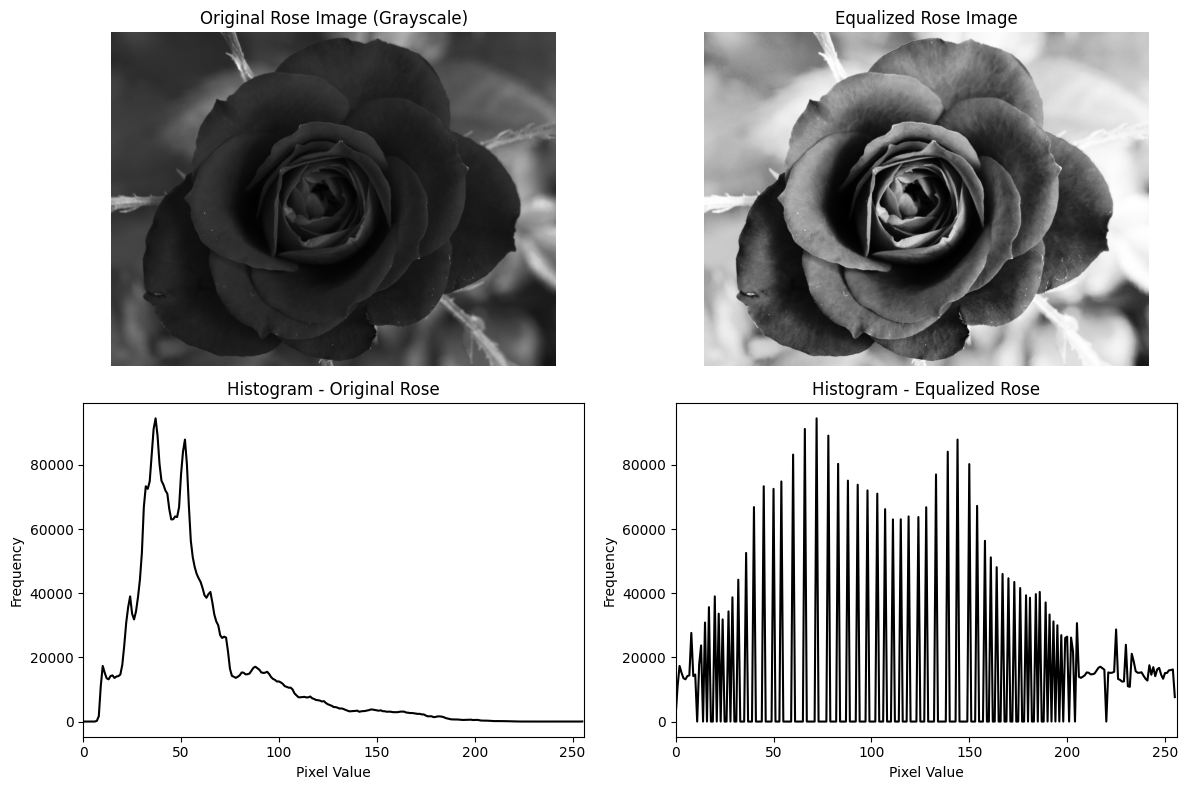

In [ ]:
import cv2
import matplotlib.pyplot as plt
import urllib.request
import numpy as np
import shutil # Import shutil for file copying

# Image URL provided by the user
image_url = "https://upload.wikimedia.org/wikipedia/commons/5/51/Small_Red_Rose.JPG"
image_filename = "rose.jpg"

# Download the image with a User-Agent header to avoid 403 Forbidden error
try:
    # Create a request with a User-Agent header
    req = urllib.request.Request(image_url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(image_filename, 'wb') as out_file:
        shutil.copyfileobj(response, out_file)
    print(f"Image downloaded successfully to {image_filename}")
except urllib.error.HTTPError as e:
    print(f"HTTP Error: {e.code} - {e.reason}")
    print(f"Could not download image from {image_url}. Please check the URL or try again later.")
    img_rose = None # Set img_rose to None if download fails
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    img_rose = None # Set img_rose to None if download fails

# Read the image in grayscale
if 'img_rose' not in locals() or img_rose is None:
    img_rose = cv2.imread(image_filename, cv2.IMREAD_GRAYSCALE)


if img_rose is None:
    print(f"Error: Could not load image from {image_filename}. Please ensure it downloaded correctly.")
else:
    # Histogram Equalization
    img_rose_eq = cv2.equalizeHist(img_rose)

    # Calculate Histograms
    hist_rose_original = cv2.calcHist([img_rose], [0], None, [256], [0, 256])
    hist_rose_equalized = cv2.calcHist([img_rose_eq], [0], None, [256], [0, 256])

    # Display images and histograms
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(img_rose, cmap='gray')
    plt.title("Original Rose Image (Grayscale)")
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(img_rose_eq, cmap='gray')
    plt.title("Equalized Rose Image")
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.plot(hist_rose_original, color='black')
    plt.title("Histogram - Original Rose")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.xlim([0, 256])

    plt.subplot(2, 2, 4)
    plt.plot(hist_rose_equalized, color='black')
    plt.title("Histogram - Equalized Rose")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()